In [1]:
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd

import sys

from pathlib import Path
nb_dir = Path.cwd()
help_func_path = os.path.join(nb_dir,'helper_code')

sys.path.append(help_func_path) 

from plotting_functions import scatter_helper, plot_3d_scatters
from saving_functions import save_dataset

In [2]:
# generate a list of random seeds to use for saving data

# rng = np.random.default_rng(42)
# num_seeds = 10
# random_seeds_lst = rng.integers(0, 2**20, size=num_seeds).tolist()

random_seeds_lst = [42,980]

In [3]:
def isotropic_gaussian(n_samples, n_features,scale=1, random_state=None):
    rng = np.random.default_rng(seed=random_state)
    return scale*rng.standard_normal((n_samples, n_features))

In [4]:
n_samples = 300
n_features = 5
scale_param = 2.5

X = isotropic_gaussian(n_samples, n_features,scale=scale_param, random_state=0)


In [5]:
X[:, 0].shape, X[:, 1].shape

((300,), (300,))

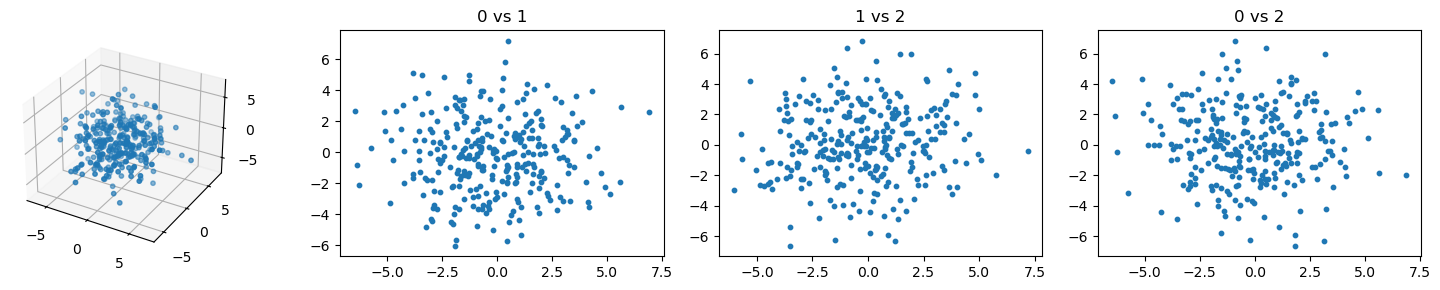

In [6]:
plot_3d_scatters(X,'',y=None)

In [7]:
from itertools import product

In [10]:
DATA_ROOT = Path(os.environ["EPHEMERAL"]) / "pyspoc_synthetic_data"
DATA_ROOT.mkdir(parents=True, exist_ok=True)

In [ ]:
dataset_type = 'spherical_gaussian_cloud'
data_root_dir = DATA_ROOT

# n_samples_lst = [1000,5000,10000]
# n_features_lst = [3,10,100,1000,5000]

n_samples_lst = [1000,10000]
n_features_lst = [10,100,1000,10000]
scale_params_lst = [0.1,1.0,3.0,10.0]

for scale_param in scale_params_lst:
    for n_samples, n_features in product(n_samples_lst, n_features_lst):
        
        # print(n_samples, n_features, X.shape)

        for sample_num,seed in enumerate(random_seeds_lst):
            
            # print(n_features,seed)
            
            X = isotropic_gaussian(n_samples, n_features,scale=scale_param, random_state=seed)
            params_dict = {
                # 'N' : n_samples,
                # 'P' : n_features
                # 'seed' : seed
                'scale' : scale_param,
            }
                            
            try:
                save_dataset(X, 
                            generator='isotropic_gaussian',
                            params=params_dict,
                            seed=seed,
                            category=['density'],
                            root=data_root_dir)

            except:
                print('file already exists')
        
        print(f'saved for {n_samples,n_features,scale_param}')

## example plotting code from manifest 
(TODO - move to separate visualization notebook in future iterations)

In [12]:
m = pd.read_csv(DATA_ROOT / "manifest.csv")
N = 1000
P = 100
seed=42
generator = 'isotropic_gaussian'
m = m[(m.n_rows == N) & (m.n_cols == P) & (m.seed == seed) & (m.generator == generator)]
m

,dataset_id,generator,category,n_rows,n_cols,params_id,seed,extra_files
2,isotropic_gaussian/params0/seed42_N1000_P100,isotropic_gaussian,['density'],1000,100,params0,42,NaN
18,isotropic_gaussian/params1/seed42_N1000_P100,isotropic_gaussian,['density'],1000,100,params1,42,NaN
34,isotropic_gaussian/params2/seed42_N1000_P100,isotropic_gaussian,['density'],1000,100,params2,42,NaN
50,isotropic_gaussian/params3/seed42_N1000_P100,isotropic_gaussian,['density'],1000,100,params3,42,NaN


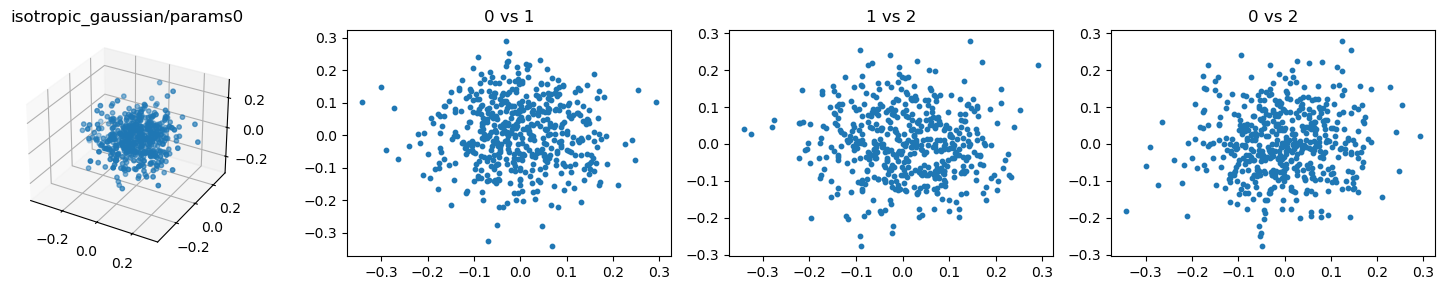

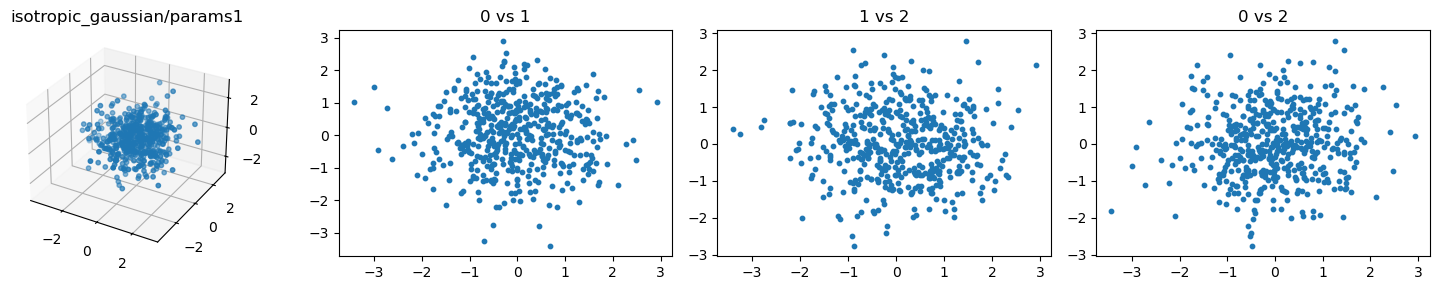

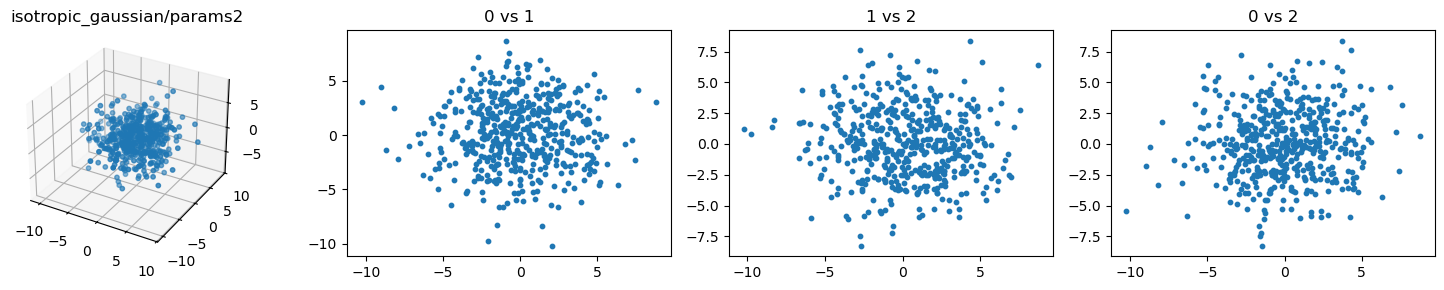

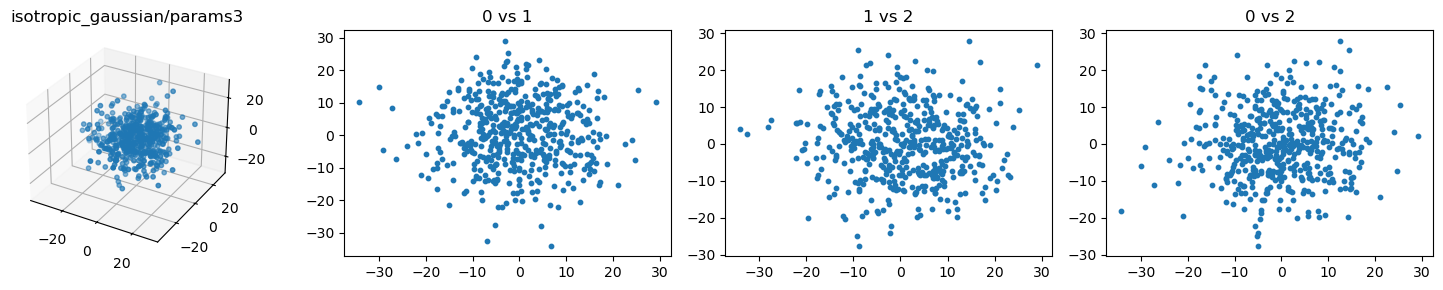

In [14]:
max_pts = 500
for r in m.groupby(["generator", "params_id"]).head(1).itertuples():
    X = np.load(DATA_ROOT / f"{r.dataset_id}.npy")
    if len(X) > max_pts:
        rng = np.random.default_rng(0)       
        X = X[rng.choice(len(X), max_pts, replace=False)]
    plot_3d_scatters(X, f"{r.generator}/{r.params_id}")